In [1]:
!pip install terratorch

    kubernetes (>=9.0.0a1.0) ; extra == 'all_extras'
               ~~~~~~~~~~^


In [2]:
from pathlib import Path

import torch
import rioxarray as rxr
from huggingface_hub import hf_hub_download
from terratorch.registry import BACKBONE_REGISTRY

# Select device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

## Patch Extraction Around Label Points 

In [58]:
import xarray as xr
import rioxarray

ds = xr.open_dataset("./data_FM/s2/s2_2024.nc", engine="h5netcdf")

# attach CRS if not already present
#if not ds.rio.crs:
#    ds = ds.rio.write_crs("EPSG:3832")

ds

/srv/conda/envs/notebook/lib/python3.11/site-packages/xarray_sentinel/esa_safe.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


<xarray.Dataset> Size: 53GB
Dimensions:          (time: 1, y: 19200, x: 28800)
Coordinates:
  * y                (y) float64 154kB -1.888e+06 -1.888e+06 ... -2.08e+06
  * x                (x) float64 230kB 2.952e+06 2.952e+06 ... 3.24e+06 3.24e+06
    spatial_ref      int32 4B ...
  * time             (time) datetime64[ns] 8B 2024-01-01
Data variables:
    COASTAL_AEROSOL  (time, y, x) float64 4GB ...
    BLUE             (time, y, x) float64 4GB ...
    GREEN            (time, y, x) float64 4GB ...
    RED              (time, y, x) float64 4GB ...
    RED_EDGE_1       (time, y, x) float64 4GB ...
    RED_EDGE_2       (time, y, x) float64 4GB ...
    RED_EDGE_3       (time, y, x) float64 4GB ...
    NIR_BROAD        (time, y, x) float64 4GB ...
    NIR_NARROW       (time, y, x) float64 4GB ...
    CIRRUS           (time, y, x) float64 4GB ...
    SWIR_1           (time, y, x) float64 4GB ...
    SWIR_2           (time, y, x) float64 4GB ...

In [59]:
import pandas as pd
points = pd.read_csv("./data_FM/label/label.csv")  

In [60]:
import geopandas as gpd
from shapely.geometry import Point
import numpy as np 

# build GeoDataFrame
gdf = gpd.GeoDataFrame(points, geometry=gpd.points_from_xy(points.lon, points.lat), crs="EPSG:4326")

# reproject to match S2 CRS
gdf = gdf.to_crs(ds.rio.crs)

X, Y = [], []
patch_size = 32
half = patch_size // 2

for _, row in gdf.iterrows():
    label = row["class_id"]
    x = row.geometry.x
    y = row.geometry.y
    
    # find nearest pixel indices
    ref_band = ds["RED"]
    x_res = float((ref_band.x[1] - ref_band.x[0]).item())
    y_res = float((ref_band.y[1] - ref_band.y[0]).item())
    
    x0 = float(ref_band.x[0].item())
    y0 = float(ref_band.y[0].item())

    px = int((x - x0) / x_res)
    py = int((y - y0) / y_res)
        
    # extract patch around the point
    patch = ds.isel(
        x=slice(px-half, px+half),
        y=slice(py-half, py+half),
        time=0
    ).to_array().transpose("y", "x", "variable").values

    #if patch.shape[0] == patch_size and patch.shape[1] == patch_size:
    #    X.append(patch)
    #    Y.append(label)
     # If patch is smaller than patch_size -> pad with NaN
    h, w, c = patch.shape
    if h != patch_size or w != patch_size:
        padded = np.full((patch_size, patch_size, c), np.nan, dtype=np.float32)
        padded[:h, :w, :] = patch
        patch = padded
        
    # Append
    X.append(patch)
    Y.append(label)



    
# stack final dataset
X = np.stack(X)
Y = np.array(Y)
print("Final dataset:", X.shape, Y.shape)



Final dataset: (10695, 32, 32, 12) (10695,)


Class_id : 1


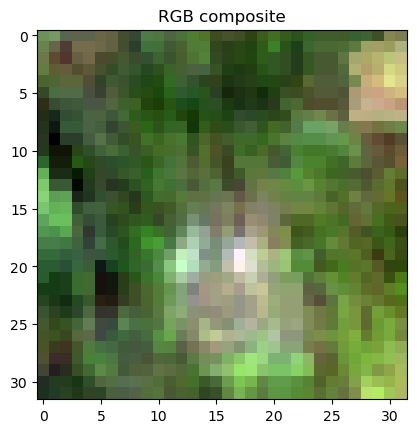

In [61]:
import matplotlib.pyplot as plt
import numpy as np

idx = 1

rgb = X[idx, :, :, [1,2,3]]
rgb = np.transpose(rgb, (1, 2, 0))
rgb_norm = (rgb - rgb.min(axis=(0,1))) / (rgb.max(axis=(0,1)) - rgb.min(axis=(0,1)))


print(f"Class_id : {Y[idx]}")

plt.imshow(rgb_norm)
plt.title("RGB composite")
plt.show()


In [73]:
import os
import shutil
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
from sklearn.model_selection import train_test_split

# ----------------------------
# Configuration
# ----------------------------
patch_size = 32

band_order = [
    "COASTAL_AEROSOL", "BLUE", "GREEN", "RED",
    "RED_EDGE_1", "RED_EDGE_2", "RED_EDGE_3",
    "NIR_BROAD", "NIR_NARROW", "CIRRUS", "SWIR_1", "SWIR_2"
]
"""
band_order = ["bs_pc_50", "pv_pc_50", "npv_pc_50"]
"""
base_path = "./data_FM/s2/patch"
folders = ["train", "validation", "test"]

# Example placeholders for your data
# X: np.array of shape (num_samples, patch_size, patch_size, num_bands)
# Y: np.array of shape (num_samples,) with class IDs
# ds: reference dataset object with .x and .y coordinates for transform
# Replace these with your actual data
# X, Y, ds = ...

# ----------------------------
# Prepare folders
# ----------------------------
for f in folders:
    x_dir = os.path.join(base_path, f, "X")
    y_dir = os.path.join(base_path, f, "y")

    # Remove existing folders
    if os.path.exists(x_dir):
        shutil.rmtree(x_dir)
    if os.path.exists(y_dir):
        shutil.rmtree(y_dir)

    # Recreate folders
    os.makedirs(x_dir, exist_ok=True)
    os.makedirs(y_dir, exist_ok=True)

# ----------------------------
# Train/validation/test split
# ----------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

splits = {
    "train": (X_train, y_train),
    "validation": (X_val, y_val),
    "test": (X_test, y_test)
}

# ----------------------------
# Function to save patches and labels
# ----------------------------
def save_patches_and_labels(X_data, y_data, folder, ref_ds, start_idx=0):
    """
    Save image patches as GeoTIFF and labels as .npy files.
    Each label filename matches the corresponding patch filename.
    """
    for i in range(X_data.shape[0]):
        patch = X_data[i]  # shape: (H, W, C)
        label = int(y_data[i])

        # Compute transform
        transform = from_origin(
            ref_ds.x[0], ref_ds.y[0],
            ref_ds.x[1] - ref_ds.x[0],
            ref_ds.y[1] - ref_ds.y[0]
        )


        # Convert to (bands, height, width)
        patch_tif = np.transpose(patch, (2, 0, 1)).astype(np.float32)

        # Save patch GeoTIFF
        patch_name = f"patch_{start_idx + i}.tif"
        patch_path = os.path.join(base_path, folder, "X", patch_name)

        with rasterio.open(
            patch_path,
            "w",
            driver="GTiff",
            height=patch_tif.shape[1],
            width=patch_tif.shape[2],
            count=patch_tif.shape[0],
            dtype=patch_tif.dtype,
            crs=ref_ds.rio.crs,
            transform=transform
        ) as dst:
            dst.write(patch_tif)

        # Save label as .npy
        label_path = os.path.join(base_path, folder, "y", f"patch_{start_idx + i}.npy")
        np.save(label_path,np.int64(label-1))

    return start_idx + X_data.shape[0]

# ----------------------------
# Save all splits
# ----------------------------
idx = 0
for split_name, (X_split, y_split) in splits.items():
    idx = save_patches_and_labels(X_split, y_split, split_name, ds, start_idx=idx)

print("All patches saved as GeoTIFFs and labels as individual .npy files!")


All patches saved as GeoTIFFs and labels as individual .npy files!


In [74]:
import rasterio
import os

patch_path = "./data_FM/s2/patch/train/y/patch_0.npy"

patch = np.load(patch_path)

print("Patch shape:", patch.shape)
print("Patch dtype:", patch.dtype)
print("Patch type:", type(patch))



Patch shape: ()
Patch dtype: int64
Patch type: <class 'numpy.ndarray'>


## Model

In [3]:
print("Available backbones:\n")
for source_name, source in BACKBONE_REGISTRY._sources.items():
    print(f"\nSource: {source_name}")
    for name in source:
        print(f"  - {name}")

Available backbones:


Source: terratorch
  - prithvi_eo_tiny
  - prithvi_eo_v1_100
  - prithvi_eo_v2_300
  - prithvi_eo_v2_600
  - prithvi_eo_v2_300_tl
  - prithvi_eo_v2_600_tl
  - dofa_small_patch16_224
  - dofa_base_patch16_224
  - dofa_large_patch16_224
  - dofa_huge_patch16_224
  - satlas_swin_t_sentinel2_mi_ms
  - satlas_swin_t_sentinel2_mi_rgb
  - satlas_swin_t_sentinel2_si_ms
  - satlas_swin_t_sentinel2_si_rgb
  - satlas_swin_b_sentinel2_mi_ms
  - satlas_swin_b_sentinel2_mi_rgb
  - satlas_swin_b_sentinel2_si_ms
  - satlas_swin_b_sentinel2_si_rgb
  - satlas_swin_b_naip_mi_rgb
  - satlas_swin_b_naip_si_rgb
  - satlas_swin_b_landsat_mi_ms
  - satlas_swin_b_landsat_mi_rgb
  - satlas_swin_b_sentinel1_mi
  - satlas_swin_b_sentinel1_si
  - ssl4eol_resnet18_landsat_tm_toa_moco
  - ssl4eol_resnet18_landsat_tm_toa_simclr
  - ssl4eol_resnet18_landsat_etm_toa_moco
  - ssl4eol_resnet18_landsat_etm_toa_simclr
  - ssl4eol_resnet18_landsat_etm_sr_moco
  - ssl4eol_resnet18_landsat_etm_sr_simclr

In [ ]:
import lightning.pytorch as pl
from omegaconf import OmegaConf
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.tasks import ClassificationTask
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch import Trainer
import torch


#  Load YAML config
cfg_path = "fiji.yaml"  # replace with your YAML path
cfg = OmegaConf.load(cfg_path)


#  Instantiate DataModule
dm = GenericMultiModalDataModule(**cfg.data.init_args)



#  Instantiate Model / Task
task = ClassificationTask(**cfg.model.init_args)

trainer = pl.Trainer(**cfg.trainer)
# Start training
trainer.fit(model=task, datamodule=dm)
  

In [3]:
from terratorch.datamodules import GenericMultiModalDataModule
from terratorch.datasets import HLSBands
import albumentations
 
means_s2 =  [1390.458, 1503.317, 1718.197, 1853.910,
         2199.100, 2779.975, 2987.011, 3083.234,
         3132.220, 3162.988, 2424.884, 2000.0]
    
stds_s2 = [2106.761, 2141.107, 2038.973, 2134.138,
     2085.321, 1889.926, 1820.257, 1871.918,
     1753.829, 1797.379, 1434.261, 1500.0]

means_fc = [7.357245445251465, 75.06333923339844, 14.884675025939941]
stds_fc = [4.740213394165039, 14.439167976379395, 12.283880233764648]

my_bands_s2 = [
    'COASTAL_AEROSOL', 'BLUE', 'GREEN', 'RED',
    'RED_EDGE_1', 'RED_EDGE_2', 'RED_EDGE_3',
    'NIR_BROAD', 'NIR_NARROW', 'CIRRUS', 'SWIR_1', 'SWIR_2'
]

my_bands_fc = ["bs_pc_50", "pv_pc_50", "npv_pc_50"]


datamodule = GenericMultiModalDataModule(
    task="classification",
    batch_size=16,
    num_workers=4,
    num_classes=7,

    # Define your input modalities. The names must match the keys in the following dicts.
    modalities=["S2L2A"],

    rgb_modality="S2L2A",  # Used for plotting. Defaults to the first modality if not provided.
    rgb_indices=[3,2,1],  # RGB channel positions in the rgb_modality.

    # Define data paths as dicts using the modality names as keys.
    train_data_root={
        "S2L2A": "./data_FM/s2/patch/train/X",
    },
    train_label_data_root="./data_FM/s2/patch/train/y",
    val_data_root={
        "S2L2A": "./data_FM/s2/patch/validation/X",
    },
    val_label_data_root="./data_FM/s2/patch/validation/y",
    test_data_root={
        "S2L2A":"./data_FM/s2/patch/test/X",
    },
    test_label_data_root="./data_FM/s2/patch/test/y",

    
    # Define suffix, again using dicts.
    img_grep={
        "S2L2A": "*.tif",
    },
    label_grep="*.npy",
    
    # With TerraTorch, you can select a subset of the dataset bands as model inputs by providing dataset_bands (all bands in the data) and output_bands (selected bands). This setting is optional for all modalities and needs to be provided as dicts.
    # Here is an example for with S-1 GRD. You could change the output to ["VV"] to only train on the first band. Note that means and stds must be aligned with the output_bands (equal length of values). 
    dataset_bands={
        "S2L2A": my_bands_s2,
    },
    output_bands={
        "S2L2A": my_bands_s2,
    },


    # Define standardization values. We use the pre-training values here and providing the additional modalities is not a problem, which makes it simple to experiment with different modality combinations. Alternatively, use the dataset statistics that you can generate using `terratorch compute_statistics -c config.yaml` (requires concat_bands: true for this multimodal datamodule).
    means={
        "S2L2A": means_s2,
    },
    stds={
        "S2L2A": stds_s2,
    },
    
    
    no_label_replace=-1,  # Replace NaN labels. defaults to -1 which is ignored in the loss and metrics.
    no_data_replace=0,  # Replace NaN data
)
# we want to access some properties of the train dataset later on, so lets call setup here
# if not, we would not need to
datamodule.setup("fit")


In [4]:
# checking datasets validation split size
val_dataset = datamodule.train_dataset
len(val_dataset)

7486

In [5]:
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

1605

In [6]:
from terratorch.registry import BACKBONE_REGISTRY, TERRATORCH_BACKBONE_REGISTRY, TERRATORCH_DECODER_REGISTRY

In [7]:
# Print all TerraMind v1 backbones.  
[backbone   
 for backbone in TERRATORCH_BACKBONE_REGISTRY
 if 'terramind_v1' in backbone]
# TiM models are using the Thinking-in-Modalities approach, see our paper for details.

['terramind_v1_base',
 'terramind_v1_base_tim',
 'terramind_v1_large',
 'terramind_v1_large_tim']

In [8]:
model = BACKBONE_REGISTRY.build(
    "terramind_v1_base",
    modalities=["S2L2A"],
    pretrained=True,
)

In [9]:
model

TerraMindViT(
  (encoder_embeddings): ModuleDict(
    (untok_sen2l2a@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=3072, out_features=768, bias=False)
    )
  )
  (encoder): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm()
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=False)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=False)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm()
      (mlp): GatedMlp(
        (fc1): Linear(in_features=768, out_features=2048, bias=False)
        (act): SiLU()
        (fc2): Linear(in_features=2048, out_features=768, bias=False)
        (fc3): Linear(in_features=768, out_features=2048, bias=False)
      )
    )
  )
  (encoder_norm): LayerNorm()
)

In [20]:
import terratorch
import lightning.pytorch as pl
pl.seed_everything(0)

# By default, TerraTorch saves the model with the best validation loss. You can overwrite this by defining a custom ModelCheckpoint, e.g., saving the model with the highest validation mIoU.  
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="output/terramind_base/checkpoints/",
    mode="max",
    monitor="val/loss", # Variable to monitor
    filename="best-loss",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision="16-mixed",  # Speed up training with half precision, delete for full precision training.
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=100, # For demos
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, pl.callbacks.RichProgressBar()],
    default_root_dir="./data_FM/output/",
)

# Segmentation mask that build the model and handles training and validation steps.  
model = terratorch.tasks.ClassificationTask(
    model_factory="EncoderDecoderFactory",  # Combines a backbone with necks, the decoder, and a head
    model_args={
        # TerraMind backbone
        "backbone": "terramind_v1_base", # large version: terramind_v1_large 
        "backbone_pretrained": True,
        "backbone_modalities": ["S2L2A"],
       "necks": [
            {"name": "SelectIndices", "indices": [2, 5, 8, 11]}, 
            {"name": "ReshapeTokensToImage", "remove_cls_token": False},  
        ],

        # Decoder
        "decoder": "FCNDecoder",
        "decoder_num_convs": 4,
        "decoder_channels": 256,
        
        "num_classes": 7,
        "head_dropout": 0.1,
    },
    loss="ce",
    optimizer="AdamW",
    lr=2e-5,  # The optimal learning rate varies between datasets, we recommend testing different once between 1e-5 and 1e-4. You can perform hyperparameter optimization using terratorch-iterate.  
    ignore_index=-1,
    freeze_backbone=True, # Only used to speed up fine-tuning in this demo, we highly recommend fine-tuning the backbone for the best performance. 
    freeze_decoder=True  # Should be false in most cases as the decoder is randomly initialized.
)

Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [ ]:
trainer.fit(model, datamodule=datamodule)

/srv/conda/envs/notebook/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:654: Checkpoint directory /home/jovyan/fc/output/terramind_base/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type              ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ ScalarOutputModel │ 91.3 M │ train │
│ 1 │ criterion     │ CrossEntropyLoss  │      0 │ train │
│ 2 │ train_metrics │ MetricCollection  │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection  │      0 │ train │
│ 4 │ test_metrics  │ ModuleList        │      0 │ train │
└───┴───────────────┴───────────────────┴────────┴───────┘

Trainable params: 1.8 K                                                                                            
Non-trainable params: 91.3 M                                                                                       
Total params: 91.3 M                                                                                               
Total estimated model params size (MB): 365                                                                        
Modules in train mode: 239                                                                                         
Modules in eval mode: 0

Output()

/srv/conda/envs/notebook/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The 
``compute`` method of metric MulticlassAccuracy was called before the ``update`` method which may lead to errors, 
as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

/srv/conda/envs/notebook/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: The 
``compute`` method of metric MulticlassJaccardIndex was called before the ``update`` method which may lead to 
errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)

In [18]:
print("Best checkpoint path:", checkpoint_callback.best_model_path)

# Print the best monitored metric value
print("Best val/loss:", checkpoint_callback.best_model_score)

Best checkpoint path: /home/jovyan/fc/output/terramind_base/checkpoints/best-loss.ckpt
Best val/mIoU: tensor(1.6176, device='cuda:0')


In [19]:
# Let's test the fine-tuned model
best_ckpt_path = "output/terramind_base/checkpoints/best-loss.ckpt"
trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)

# Note: This demo only trains for 5 epochs by default, which does not result in good test metrics.

Restoring states from the checkpoint path at output/terramind_base/checkpoints/best-loss.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at output/terramind_base/checkpoints/best-loss.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Test metric          ┃         DataLoader 0          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     test/Average_Accuracy     │      0.13894890248775482      │
│   test/Multiclass_F1_Score    │      0.4728972017765045       │
│ test/Multiclass_Jaccard_Index │      0.0694022849202156       │
│     test/Overall_Accuracy     │      0.4728972017765045       │
│           test/loss           │      1.6173913478851318       │
│   test/multiclassaccuracy_0   │      0.9642857313156128       │
│   test/multiclassaccuracy_1   │              0.0              │
│   test/multiclassaccuracy_2   │     0.008356546051800251      │
│   test/multiclassaccuracy_3   │              0.0              │
│   test/multiclassaccuracy_4   │              0.0              │
│   test/multiclassaccuracy_5   │              0.0              │
│   test/multiclassaccuracy_6   │              0.0              │
│ test/multiclassjaccardindex_0 │      0.4784810245037079       │
│ test/multiclassjaccardindex_1 │              0.0              │
│ test/multiclassjaccardindex_2 │     0.007334963418543339      │
│ test/multiclassjaccardindex_3 │              0.0              │
│ test/multiclassjaccardindex_4 │              0.0              │
│ test/multiclassjaccardindex_5 │              0.0              │
│ test/multiclassjaccardindex_6 │              0.0              │
└───────────────────────────────┴───────────────────────────────┘

[{'test/loss': 1.6173913478851318,
  'test/Average_Accuracy': 0.13894890248775482,
  'test/multiclassaccuracy_0': 0.9642857313156128,
  'test/multiclassaccuracy_1': 0.0,
  'test/multiclassaccuracy_2': 0.008356546051800251,
  'test/multiclassaccuracy_3': 0.0,
  'test/multiclassaccuracy_4': 0.0,
  'test/multiclassaccuracy_5': 0.0,
  'test/multiclassaccuracy_6': 0.0,
  'test/Multiclass_F1_Score': 0.4728972017765045,
  'test/Multiclass_Jaccard_Index': 0.0694022849202156,
  'test/multiclassjaccardindex_0': 0.4784810245037079,
  'test/multiclassjaccardindex_1': 0.0,
  'test/multiclassjaccardindex_2': 0.007334963418543339,
  'test/multiclassjaccardindex_3': 0.0,
  'test/multiclassjaccardindex_4': 0.0,
  'test/multiclassjaccardindex_5': 0.0,
  'test/multiclassjaccardindex_6': 0.0,
  'test/Overall_Accuracy': 0.4728972017765045}]